# Preliminary

In [ ]:
%matplotlib inline
# Importing the course packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the course datasets 
climate_change = pd.read_csv('../datasets/climate_change.csv', parse_dates=["date"], index_col="date")
medals = pd.read_csv('../datasets/medals_by_country_2016.csv', index_col=0)
summer_2016 = pd.read_csv('../datasets/summer2016.csv')
austin_weather = pd.read_csv("../datasets/austin_weather.csv", index_col="DATE")
weather = pd.read_csv("../datasets/seattle_weather.csv", index_col="DATE")

# Some pre-processing on the weather datasets, including adding a month column
seattle_weather = weather[weather["STATION"] == "USW00094290"] 
month = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"] 
seattle_weather.loc[:,"MONTH"] = month 
austin_weather.loc[:,"MONTH"] = month

# Plotting time-series data

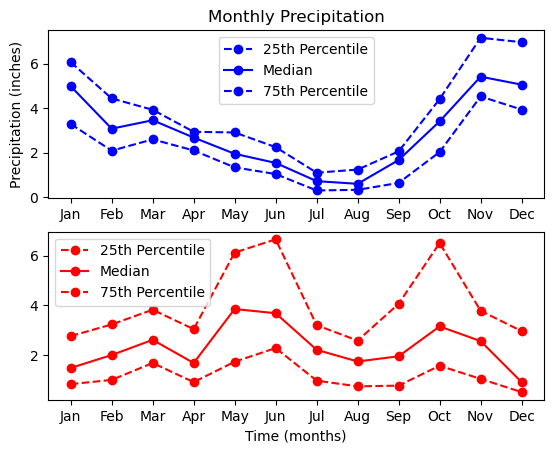

In [14]:
# Weather datasets are an example (obviously)
fig, ax = plt.subplots(2,1)

yvals = ["MLY-PRCP-25PCTL","MLY-PRCP-50PCTL","MLY-PRCP-75PCTL"]

for val in yvals:
    ax[0].plot(seattle_weather["MONTH"], seattle_weather[val],color='b',linestyle="dashed" if val != "MLY-PRCP-50PCTL" else "-", marker= "o")
    ax[0].legend(["25th Percentile", "Median", "75th Percentile"])

for val in yvals:
    ax[1].plot(austin_weather["MONTH"], austin_weather[val],color='r',linestyle="dashed" if val != "MLY-PRCP-50PCTL" else "-", marker= "o")
    ax[1].legend(["25th Percentile", "Median", "75th Percentile"])

ax[0].set_ylabel("Precipitation (inches)")
ax[1].set_xlabel("Time (months)")
ax[0].set_title("Monthly Precipitation")

plt.show()

## Climate Change Data

In [17]:
climate_change.head()

,co2,relative_temp
date,,
1958-03-06,315.71,0.10
1958-04-06,317.45,0.01
1958-05-06,317.50,0.08
1958-06-06,NaN,-0.05
1958-07-06,315.86,0.06


In [22]:
climate_change.index

DatetimeIndex(['1958-03-06', '1958-04-06', '1958-05-06', '1958-06-06',
               '1958-07-06', '1958-08-06', '1958-09-06', '1958-10-06',
               '1958-11-06', '1958-12-06',
               ...
               '2016-03-06', '2016-04-06', '2016-05-06', '2016-06-06',
               '2016-07-06', '2016-08-06', '2016-09-06', '2016-10-06',
               '2016-11-06', '2016-12-06'],
              dtype='datetime64[ns]', name='date', length=706, freq=None)

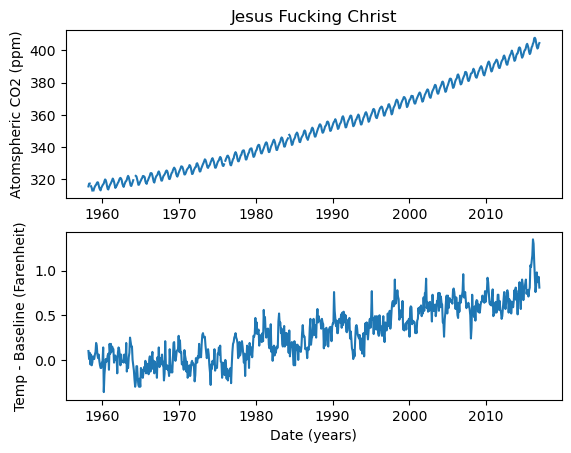

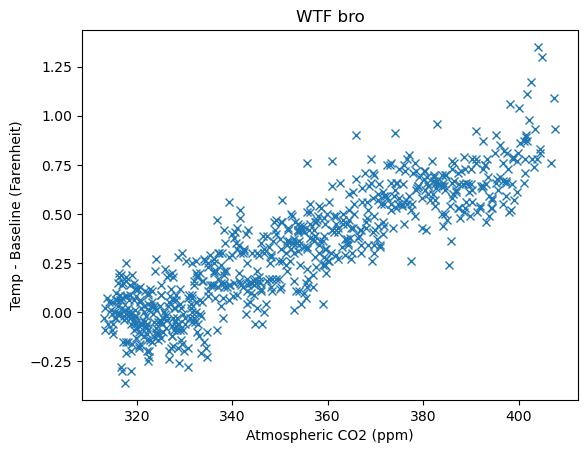

Correlation between atompsheric CO2 and deviation from baseline temp is 0.89


In [51]:
# Plotting data
fig, ax = plt.subplots(2,1)
ax[0].plot(climate_change.index, climate_change["co2"])
ax[1].plot(climate_change.index, climate_change["relative_temp"])
ax[1].set_xlabel("Date (years)")
ax[0].set_ylabel("Atomspheric CO2 (ppm)")
ax[1].set_ylabel("Temp - Baseline (Farenheit)")
ax[0].set_title("Jesus Fucking Christ")
plt.show()

fig, ax = plt.subplots()
ax.plot(climate_change["co2"],climate_change["relative_temp"],linestyle="None",marker="x")
ax.set_xlabel("Atmospheric CO2 (ppm)")
ax.set_ylabel("Temp - Baseline (Farenheit)")
ax.set_title("WTF bro")
plt.show()

print(f"Correlation between atompsheric CO2 and deviation from baseline temp is {climate_change.corr().iloc[0,1]:.2f}")

## Zooming in on a decade

- Slice the index with start date and end date

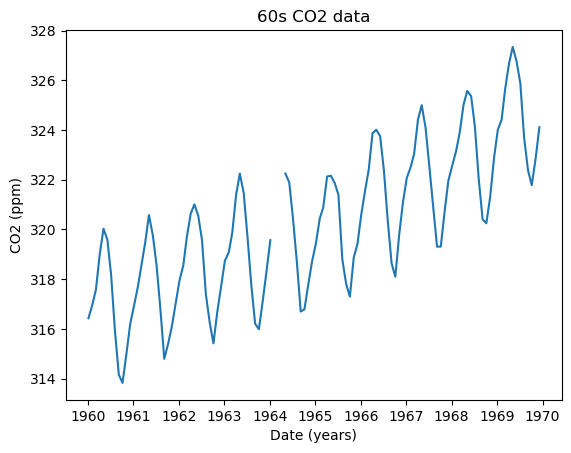

In [55]:
sixties = climate_change["1960-01-01":"1969-12-31"]
fig, ax = plt.subplots()
ax.plot(sixties.index, sixties["co2"])
ax.set_xlabel("Date (years)")
ax.set_ylabel("CO2 (ppm)")
ax.set_title("60s CO2 data")
plt.show()

# Plotting time-series with different variables

- Nothing fancy. Not sure why we're even bothering with this tbh, it's obvious.

# Method 1
fig, ax = plt.subplots()
ax.plot(climate_change.index, climate_change["co2"], climate_change.index, climate_change["relative_temp"])
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm) / Relative temperature')
plt.show()

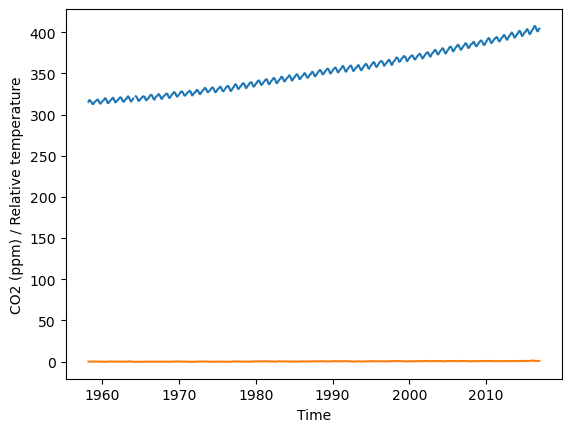

In [58]:
# Method 2
fig, ax = plt.subplots()
ax.plot(climate_change.index, climate_change["co2"])
ax.plot(climate_change.index, climate_change["relative_temp"])
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm) / Relative temperature')
plt.show()

## Using twin axes
This part is actually useful! In plots above, the two lines are useless because of the dramatically different value scales. Use two different y axis scales!

ax.twinx() will do this

Note: You can specify the color *of the labels* using a color argument!

Use "tick_params" to specify things like the colors of the tick labels (can specify y or x)

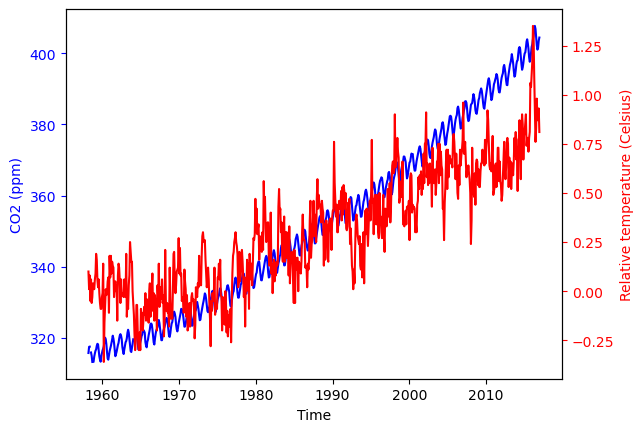

In [64]:
fig, ax = plt.subplots()
ax.plot(climate_change.index, climate_change["co2"],color="blue")
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)', color="blue")
ax.tick_params('y',colors='blue')
ax2 = ax.twinx()
ax2.plot(climate_change.index, climate_change["relative_temp"],color='r')
ax2.tick_params('y',colors='red')
ax2.set_ylabel('Relative temperature (Celsius)', color='r') 
plt.show()

## A function that plots time-series

In [65]:
def plot_timeseries(axes, x, y, color, xlabel, ylabel):
    axes.plot(x, y, color=color)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel,color=color)
    axes.tick_params('y',colors=color)

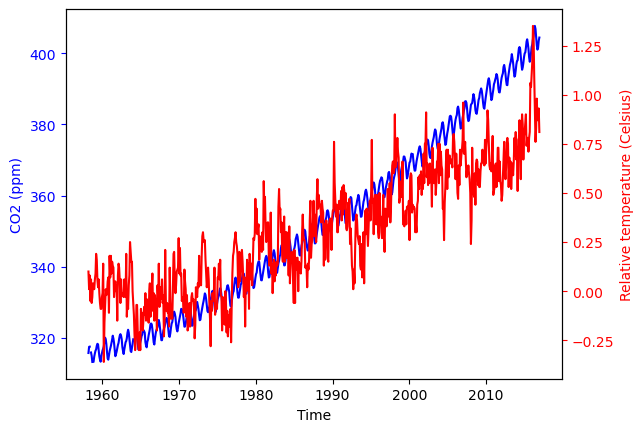

In [69]:
fig, ax = plt.subplots()
plot_timeseries(ax, climate_change.index, climate_change["co2"],"blue", "Time","CO2 (ppm)")
ax2=ax.twinx()
plot_timeseries(ax2, climate_change.index, climate_change["relative_temp"], 'r',"Time","Relative temperature (Celsius)")
plt.show()

## Annotating time-series data

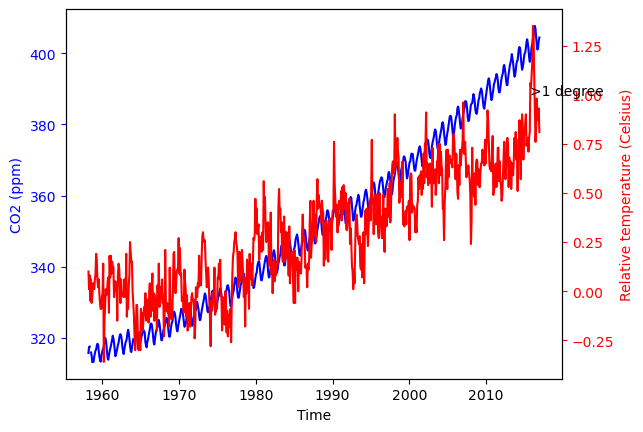

In [70]:
fig, ax = plt.subplots()
plot_timeseries(ax, climate_change.index, climate_change["co2"],"blue", "Time","CO2 (ppm)")
ax2=ax.twinx()
plot_timeseries(ax2, climate_change.index, climate_change["relative_temp"], 'r',"Time","Relative temperature (Celsius)")
ax2.annotate(">1 degree", xy=(pd.Timestamp("2015-10-06"),1)) # Looks like garbage
plt.show()

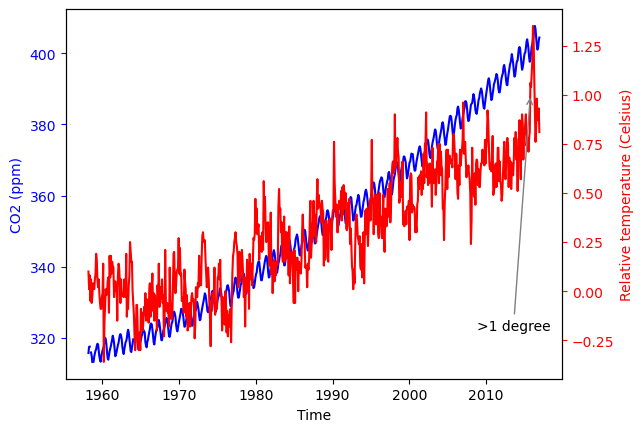

In [96]:
fig, ax = plt.subplots()
plot_timeseries(ax, climate_change.index, climate_change["co2"],"blue", "Time","CO2 (ppm)")
ax2=ax.twinx()
plot_timeseries(ax2, climate_change.index, climate_change["relative_temp"], 'r',"Time","Relative temperature (Celsius)")
ax2.annotate(">1 degree", xy=(climate_change.query("relative_temp >1").index[0],1), xytext=(pd.Timestamp('2008-10-06'),-0.2), arrowprops={"arrowstyle":"->", "color":"gray"})
plt.show()

In [95]:
climate_change.query("relative_temp"

Timestamp('2015-10-06 00:00:00')

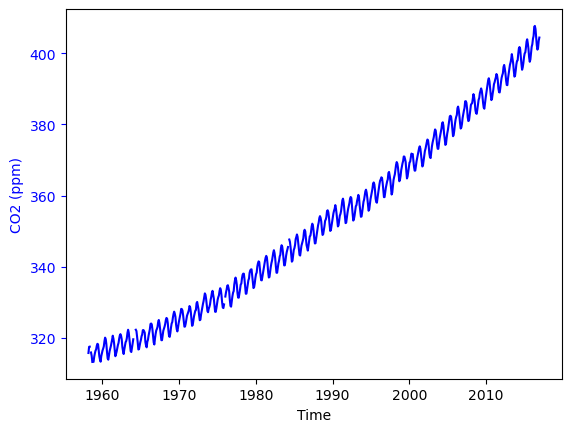

In [99]:
def query_and_annotate(data, axes, var, thresh):
    description = f"First instance of {var} > {thresh}"
    x = data.query(f"{var} > {thresh}").index[0]
    axout = axes.annotate(description, xy=(x,1))
    return axout

fig, ax = plt.subplots()
plot_timeseries(ax, climate_change.index, climate_change["co2"],"blue", "Time","CO2 (ppm)")
ax2 = query_and_annotate(climate_change, ax, "co2", 350)
plt.show()